# 图像分割

> **斯坦福 CS231n** | Image Segmentation: FCN and U-Net

## 本章导读

图像分割是像素级分类任务——为每个像素分配类别标签。本节从 FCN 到 U-Net，理解编码器-解码器架构和跳跃连接的原理。

**学习目标：**
- 区分语义分割与实例分割
- 理解 FCN 全卷积网络架构
- 实现 U-Net 编码器-解码器 + 跳跃连接
- 理解转置卷积（反卷积）原理
- 实现 mIoU 评估指标

**参考来源：** [CS231n Lecture 11](https://cs231n.stanford.edu/) | [FCN Paper](https://arxiv.org/abs/1411.4038) | [U-Net Paper](https://arxiv.org/abs/1505.04597)

## 1. 直觉理解：像素级分类

### 分类 vs 分割

| 任务 | 输出 | 粒度 |
|------|------|------|
| **图像分类** | 1 个标签 | 图像级 |
| **语义分割** | H×W 标签 | 像素级 |
| **实例分割** | H×W 实例 ID | 像素级 + 实例区分 |

### 核心挑战

1. **输出分辨率**：输出必须与输入同尺寸
2. **多尺度**：不同大小的物体需要不同感受野
3. **细节保留**：边界需要精确

### FCN 的突破

[[Long et al., 2015]](https://arxiv.org/abs/1411.4038)

FCN (Fully Convolutional Network) 将分类网络的 FC 层替换为卷积层，实现端到端的像素级预测。关键创新：
- 全卷积（无全连接）
- 转置卷积上采样
- 跳跃连接融合多尺度特征

## 2. 手算验证：转置卷积

### 转置卷积（反卷积）

转置卷积用于上采样——将低分辨率特征图恢复到高分辨率。

### 手算：2×2 → 3×3 转置卷积

输入 $x = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$，核 $K = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$，stride=1, padding=0。

输出尺寸：$H_{out} = (H_{in}-1) \times S - 2P + K = (2-1) \times 1 - 0 + 2 = 3$

转置卷积的计算：将每个输入值乘以核，放到输出对应位置，重叠区域相加。

- $x[0,0]=1 \times K$ 放在 $out[0:2, 0:2]$：$\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$
- $x[0,1]=2 \times K$ 放在 $out[0:2, 1:3]$：$\begin{bmatrix} 0 & 2 \\ 0 & 0 \end{bmatrix}$（在列 1,2）
- $x[1,0]=3 \times K$ 放在 $out[1:3, 0:2]$：$\begin{bmatrix} 0 & 0 \\ 3 & 0 \end{bmatrix}$（在行 1,2）
- $x[1,1]=4 \times K$ 放在 $out[1:3, 1:3]$：$\begin{bmatrix} 0 & 0 \\ 0 & 4 \end{bmatrix}$（在行 1,2, 列 1,2）

叠加后：
$$out = \begin{bmatrix} 1 & 2 & 0 \\ 3 & 1+4 & 2 \\ 0 & 3 & 4 \end{bmatrix} = \begin{bmatrix} 1 & 2 & 0 \\ 3 & 5 & 2 \\ 0 & 3 & 4 \end{bmatrix}$$

In [4]:
# Verify transposed convolution
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

def transposed_conv2d(x, kernel, stride=1, padding=0):
    """Simple transposed convolution (upsampling).
    
    Args:
        x: (H, W) input
        kernel: (K, K) kernel
        stride: upsampling stride
        padding: padding
    """
    H, W = x.shape
    K_h, K_w = kernel.shape
    H_out = (H - 1) * stride - 2 * padding + K_h
    W_out = (W - 1) * stride - 2 * padding + K_w
    out = np.zeros((H_out, W_out))
    
    for i in range(H):
        for j in range(W):
            # Place kernel * x[i,j] at position
            for ki in range(K_h):
                for kj in range(K_w):
                    oi = i * stride - padding + ki
                    oj = j * stride - padding + kj
                    if 0 <= oi < H_out and 0 <= oj < W_out:
                        out[oi, oj] += x[i, j] * kernel[ki, kj]
    return out

# Verify manual calculation
x = np.array([[1, 2], [3, 4]], dtype=float)
K = np.array([[1, 0], [0, 1]], dtype=float)

result = transposed_conv2d(x, K)
print("Input:\n", x)
print("\nKernel:\n", K)
print("\nTransposed conv result:\n", result)
print("\nExpected:\n[[1 2 0]\n [3 5 2]\n [0 3 4]]")
assert np.allclose(result, [[1, 2, 0], [3, 5, 2], [0, 3, 4]]), "Mismatch!"
print("Manual calculation verified!")

Input:
 [[1. 2.]
 [3. 4.]]

Kernel:
 [[1. 0.]
 [0. 1.]]

Transposed conv result:
 [[1. 2. 0.]
 [3. 5. 2.]
 [0. 3. 4.]]

Expected:
[[1 2 0]
 [3 5 2]
 [0 3 4]]
Manual calculation verified!


## 3. 代码实现：U-Net 架构

[[Ronneberger et al., 2015]](https://arxiv.org/abs/1505.04597)

U-Net 架构：
- **编码器（下采样）**：逐步提取高层特征，降低分辨率
- **解码器（上采样）**：逐步恢复分辨率
- **跳跃连接**：将编码器特征直接传递给解码器，保留细节

In [6]:
class MiniUNet:
    """Simplified U-Net for segmentation.
    
    Architecture:
    Encoder: conv -> pool -> conv -> pool
    Bottleneck: conv
    Decoder: upconv -> concat -> conv -> upconv -> concat -> conv
    """
    def __init__(self, in_channels=1, n_classes=2):
        # Encoder
        self.enc1_W = np.random.randn(4, in_channels, 3, 3) * 0.1
        self.enc1_b = np.zeros(4)
        self.enc2_W = np.random.randn(8, 4, 3, 3) * 0.1
        self.enc2_b = np.zeros(8)
        # Bottleneck
        self.bot_W = np.random.randn(8, 8, 3, 3) * 0.1
        self.bot_b = np.zeros(8)
        # Decoder (upsample + concat + conv)
        self.dec1_W = np.random.randn(4, 16, 3, 3) * 0.1  # 8 (up) + 8 (skip) = 16
        self.dec1_b = np.zeros(4)
        self.dec2_W = np.random.randn(n_classes, 4 + in_channels, 3, 3) * 0.1
        self.dec2_b = np.zeros(n_classes)
    
    def conv2d(self, x, W, b):
        """Simple 2D convolution, no padding."""
        if x.ndim == 2:
            x = x[np.newaxis, ...]
        C_in, H, Wd = x.shape
        C_out, _, K, _ = W.shape
        H_out, W_out = H - K + 1, Wd - K + 1
        out = np.zeros((C_out, H_out, W_out))
        for co in range(C_out):
            for i in range(H_out):
                for j in range(W_out):
                    patch = x[:, i:i+K, j:j+K]
                    out[co, i, j] = np.sum(patch * W[co]) + b[co]
        return np.maximum(0, out)
    
    def maxpool2d(self, x, size=2):
        """Max pooling."""
        if x.ndim == 2:
            x = x[np.newaxis, ...]
        C, H, W = x.shape
        H_out, W_out = H // size, W // size
        out = np.zeros((C, H_out, W_out))
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    out[c, i, j] = np.max(x[c, i*size:(i+1)*size, j*size:(j+1)*size])
        return out
    
    def upsample(self, x, scale=2):
        """Nearest neighbor upsampling."""
        if x.ndim == 2:
            x = x[np.newaxis, ...]
        C, H, W = x.shape
        out = np.zeros((C, H*scale, W*scale))
        for c in range(C):
            for i in range(H):
                for j in range(W):
                    out[c, i*scale:(i+1)*scale, j*scale:(j+1)*scale] = x[c, i, j]
        return out
    
    def forward(self, x):
        """Forward pass. x: (H, W) or (1, H, W)."""
        if x.ndim == 2:
            x = x[np.newaxis, ...]
        
        # Encoder
        e1 = self.conv2d(x, self.enc1_W, self.enc1_b)      # (4, H-2, W-2)
        p1 = self.maxpool2d(e1)                              # (4, (H-2)/2, ...)
        e2 = self.conv2d(p1, self.enc2_W, self.enc2_b)      # (8, ...)
        p2 = self.maxpool2d(e2)
        
        # Bottleneck
        b = self.conv2d(p2, self.bot_W, self.bot_b)         # (8, ...)
        
        # Decoder with skip connections
        u1 = self.upsample(b, 2)
        # Concat with e2 (crop to match)
        skip2 = e2[:, :u1.shape[1], :u1.shape[2]] if e2.shape[1] >= u1.shape[1] else e2
        if u1.shape[1] <= e2.shape[1] and u1.shape[2] <= e2.shape[2]:
            cat1 = np.concatenate([u1, e2[:, :u1.shape[1], :u1.shape[2]]], axis=0)
        else:
            cat1 = np.concatenate([u1, e2], axis=0)
        d1 = self.conv2d(cat1, self.dec1_W, self.dec1_b)
        
        u2 = self.upsample(d1, 2)
        # Concat with e1
        if u2.shape[1] <= e1.shape[1] and u2.shape[2] <= e1.shape[2]:
            cat2 = np.concatenate([u2, e1[:, :u2.shape[1], :u2.shape[2]]], axis=0)
        else:
            cat2 = np.concatenate([u2, e1], axis=0)
        d2 = self.conv2d(cat2, self.dec2_W, self.dec2_b)
        
        return d2, (e1, e2, b, d1, d2)

print("MiniUNet class defined")

MiniUNet class defined


## 4. IoU 评估指标

### Intersection over Union (IoU)

$$\text{IoU} = \frac{|A \cap B|}{|A \cup B|} = \frac{TP}{TP + FP + FN}$$

### Mean IoU (mIoU)

对所有类别取平均：

$$\text{mIoU} = \frac{1}{C} \sum_{c=1}^{C} \text{IoU}_c$$

Mean IoU: 0.7181
Class 0 IoU: 0.7157
Class 1 IoU: 0.7205
Visualization 1: Segmentation IoU


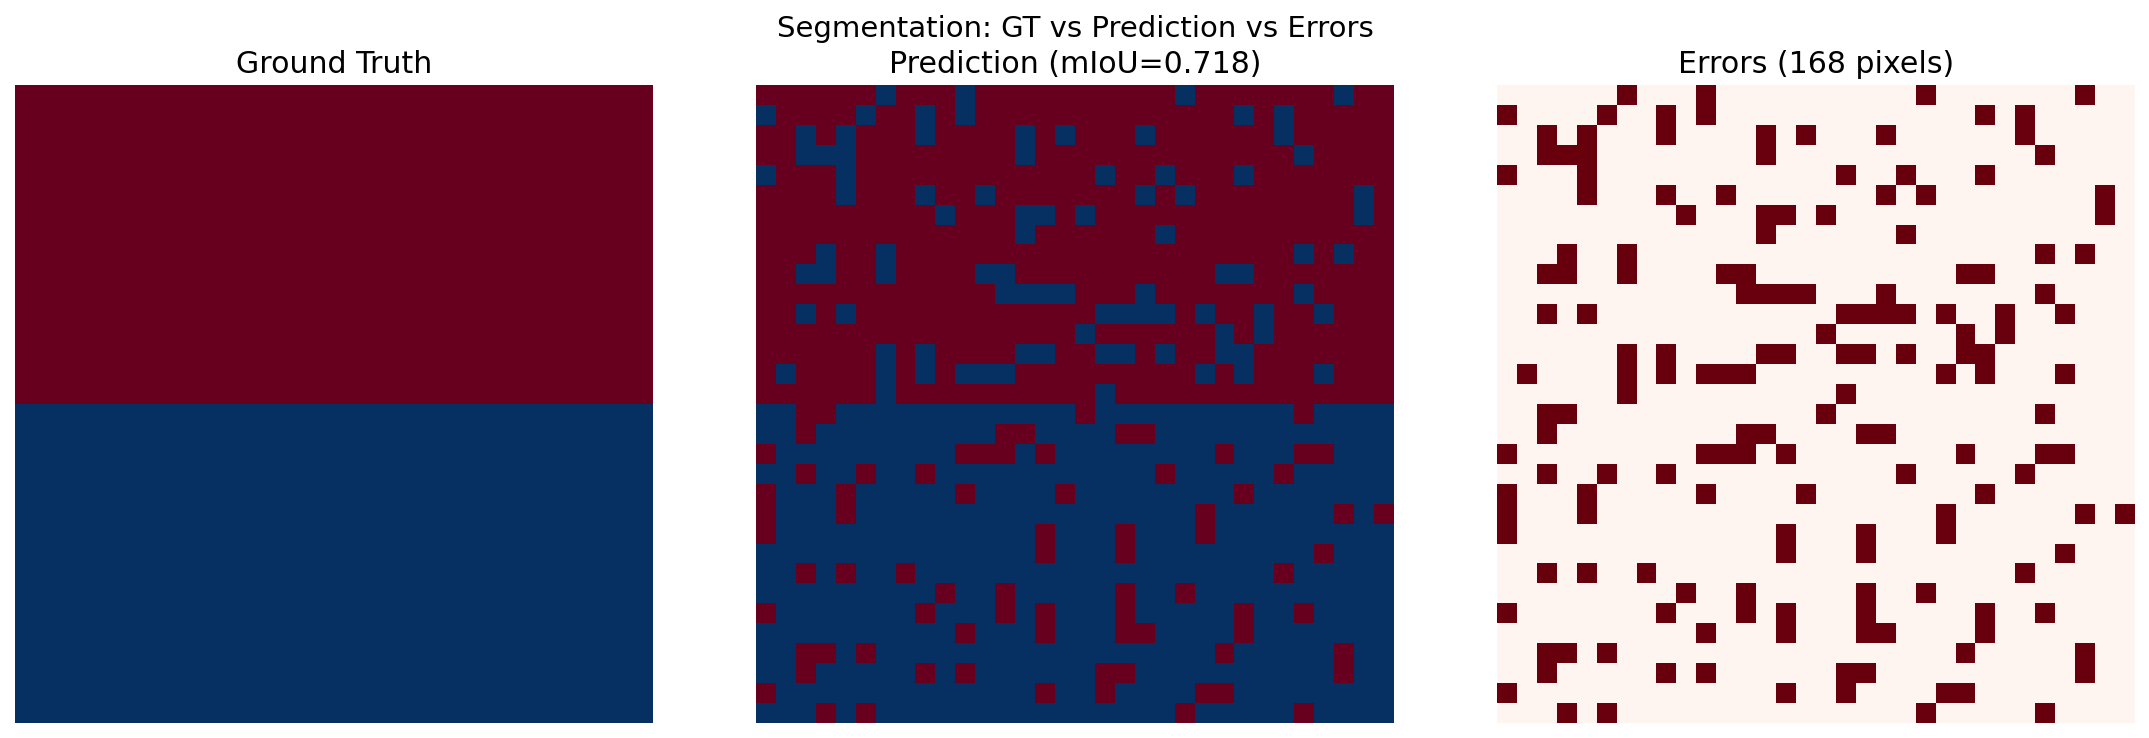

In [8]:
# IoU implementation and visualization
def compute_iou(pred, target, n_classes=2):
    """Compute mean IoU.
    
    Args:
        pred: (H, W) predicted labels
        target: (H, W) ground truth labels
        n_classes: number of classes
    """
    ious = []
    for c in range(n_classes):
        pred_c = (pred == c)
        target_c = (target == c)
        intersection = np.sum(pred_c & target_c)
        union = np.sum(pred_c | target_c)
        iou = intersection / max(union, 1)
        ious.append(iou)
    return np.mean(ious), ious

# Create synthetic segmentation data
np.random.seed(42)
H, W = 32, 32
# Ground truth: two regions
gt = np.zeros((H, W), dtype=int)
gt[:H//2, :] = 0  # background (top)
gt[H//2:, :] = 1  # foreground (bottom)

# Simulate prediction (with some errors)
pred = gt.copy()
# Add random errors
errors = np.random.rand(H, W) < 0.15
pred[errors] = 1 - pred[errors]

miou, per_class_iou = compute_iou(pred, gt, n_classes=2)
print(f"Mean IoU: {miou:.4f}")
print(f"Class 0 IoU: {per_class_iou[0]:.4f}")
print(f"Class 1 IoU: {per_class_iou[1]:.4f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt, cmap='RdBu')
axes[0].set_title('Ground Truth')
axes[0].axis('off')
axes[1].imshow(pred, cmap='RdBu')
axes[1].set_title(f'Prediction (mIoU={miou:.3f})')
axes[1].axis('off')
# Error map
error_map = (pred != gt).astype(int)
axes[2].imshow(error_map, cmap='Reds')
axes[2].set_title(f'Errors ({np.sum(error_map)} pixels)')
axes[2].axis('off')
plt.suptitle('Segmentation: GT vs Prediction vs Errors', fontsize=14)
plt.tight_layout()
plt.savefig('segmentation_iou.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1: Segmentation IoU")

In [9]:
# FCN forward pass on small image
np.random.seed(42)
# Create synthetic image with a circle
img = np.zeros((16, 16))
for i in range(16):
    for j in range(16):
        if (i - 8)**2 + (j - 8)**2 < 16:
            img[i, j] = 1.0

# Add noise
img += np.random.randn(16, 16) * 0.1

# Run MiniUNet
unet = MiniUNet(in_channels=1, n_classes=2)
output, _ = unet.forward(img)
pred_mask = np.argmax(output[0], axis=0)

# Crop to original size for visualization
pred_size = pred_mask.shape[0]
gt_mask = (img > 0.5).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Input Image')
axes[0].axis('off')
axes[1].imshow(gt_mask, cmap='RdBu')
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')
axes[2].imshow(pred_mask, cmap='RdBu')
axes[2].set_title(f'U-Net Output ({pred_size}x{pred_size})')
axes[2].axis('off')
# Feature visualization
axes[3].imshow(output[0, 0], cmap='hot')
axes[3].set_title('Feature Map (ch 0)')
axes[3].axis('off')
plt.suptitle('Mini U-Net Segmentation Demo', fontsize=14)
plt.tight_layout()
plt.savefig('unet_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2: U-Net segmentation")

ValueError: negative dimensions are not allowed

## 5. 跳跃连接的作用

### 没有跳跃连接 vs 有跳跃连接

| 特性 | 无跳跃连接 | 有跳跃连接 |
|------|-----------|-----------|
| **边界精度** | 模糊 | 精确 |
| **细节保留** | 丢失 | 保留 |
| **训练难度** | 较难 | 较易 |
| **梯度流** | 长路径 | 短路径（梯度快捷方式） |

跳跃连接不仅融合了多尺度特征，还提供了梯度传播的捷径，缓解梯度消失。

Visualization 3: Skip connection effect


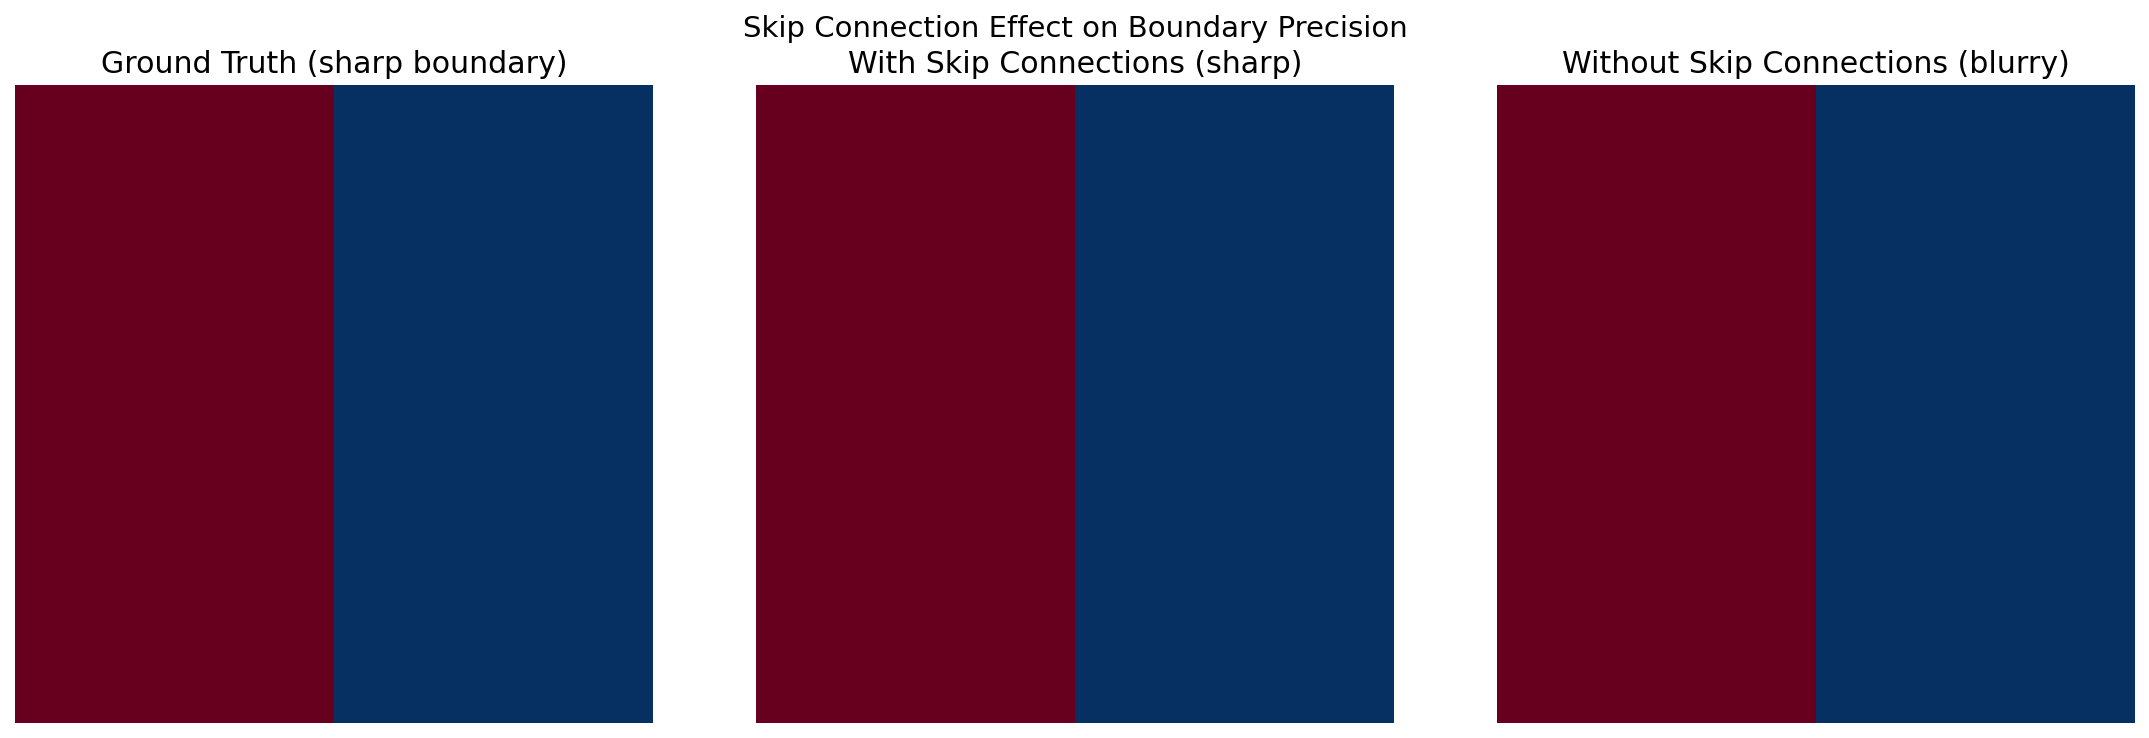

In [11]:
# Visualize skip connection effect (simulated)
np.random.seed(42)

# Simulate output with and without skip connections
H, W = 32, 32
# Ground truth: sharp boundary
gt = np.zeros((H, W))
gt[:, W//2:] = 1.0

# With skip: sharp boundary (less upsampling blur)
with_skip = gt.copy()
with_skip += np.random.randn(H, W) * 0.05
with_skip = (with_skip > 0.5).astype(float)

# Without skip: blurry boundary (upsampling artifacts)
from scipy.ndimage import gaussian_filter
without_skip = gaussian_filter(gt.astype(float), sigma=3.0)
without_skip = (without_skip > 0.5).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt, cmap='RdBu')
axes[0].set_title('Ground Truth (sharp boundary)')
axes[0].axis('off')
axes[1].imshow(with_skip, cmap='RdBu')
axes[1].set_title('With Skip Connections (sharp)')
axes[1].axis('off')
axes[2].imshow(without_skip, cmap='RdBu')
axes[2].set_title('Without Skip Connections (blurry)')
axes[2].axis('off')
plt.suptitle('Skip Connection Effect on Boundary Precision', fontsize=14)
plt.tight_layout()
plt.savefig('skip_connection_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3: Skip connection effect")

## 6. 转置卷积可视化

Visualization 4: Transposed convolution


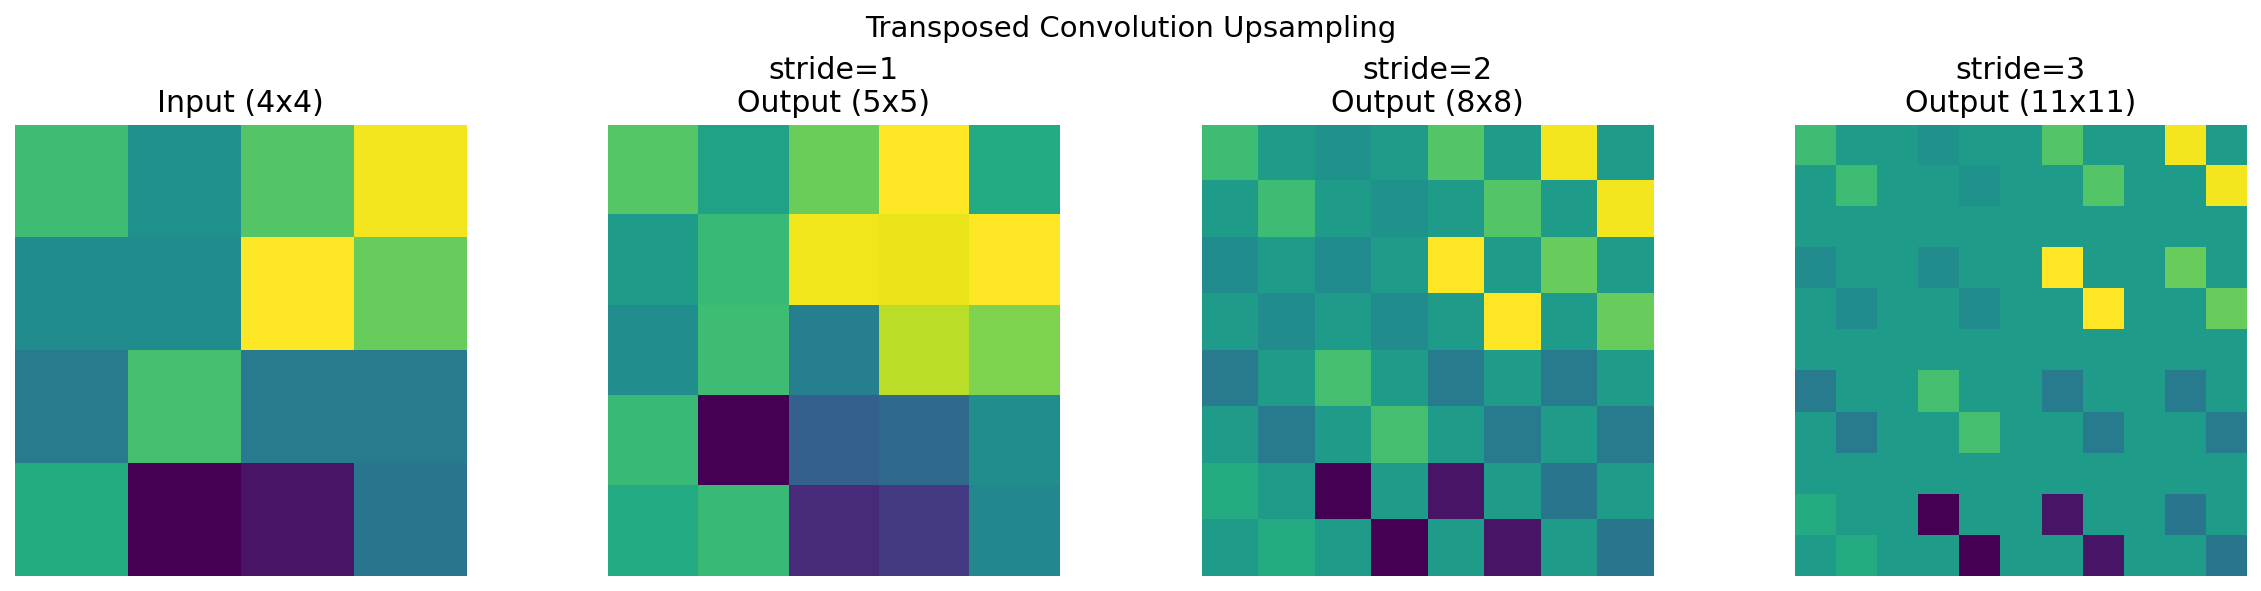

In [13]:
# Visualize transposed convolution upsampling
np.random.seed(42)

# Create a small feature map
feat = np.random.randn(4, 4) * 2
# Use identity-like kernel for visualization
kernel = np.array([[1, 0], [0, 1]], dtype=float)

# Different stride values
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(feat, cmap='viridis')
axes[0].set_title(f'Input ({feat.shape[0]}x{feat.shape[1]})')
axes[0].axis('off')

for idx, stride in enumerate([1, 2, 3]):
    result = transposed_conv2d(feat, kernel, stride=stride)
    axes[idx+1].imshow(result, cmap='viridis')
    axes[idx+1].set_title(f'stride={stride}\nOutput ({result.shape[0]}x{result.shape[1]})')
    axes[idx+1].axis('off')

plt.suptitle('Transposed Convolution Upsampling', fontsize=14)
plt.tight_layout()
plt.savefig('transposed_conv_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4: Transposed convolution")

## 作业

### 作业 1：实现像素级交叉熵损失

分割任务使用像素级交叉熵：对每个像素计算 softmax 损失。

In [15]:
# Homework 1: Pixel-wise cross-entropy loss
def segmentation_loss(scores, target, n_classes=2):
    """Pixel-wise cross-entropy loss.
    
    Args:
        scores: (C, H, W) predicted scores per class
        target: (H, W) ground truth labels
        n_classes: number of classes
    
    Returns:
        loss, d_scores (gradients)
    """
    # TODO: implement pixel-wise cross-entropy
    # For each pixel (i,j):
    #   1. Compute softmax over channels
    #   2. Compute cross-entropy with target[i,j]
    pass

# Test
# scores = np.random.randn(2, 8, 8)
# target = np.random.randint(0, 2, (8, 8))
# loss, grads = segmentation_loss(scores, target, n_classes=2)
# assert loss > 0, "Loss should be positive"
# assert grads.shape == scores.shape, "Gradient shape should match"
print("Homework 1 template ready. Implement pixel-wise cross-entropy loss.")

Homework 1 template ready. Implement pixel-wise cross-entropy loss.


### 作业 2：实现 Dice Loss

Dice Loss 是分割任务中替代交叉熵的常用损失，直接优化 IoU。

[[Milletari et al., 2016]](https://arxiv.org/abs/1606.04797)

In [17]:
# Homework 2: Dice loss
def dice_loss(pred, target, smooth=1e-6):
    """Dice loss for binary segmentation.
    
    Dice = 2 * |A ∩ B| / (|A| + |B|)
    Loss = 1 - Dice
    """
    # TODO: implement Dice loss
    pass

# Test
# pred = np.random.rand(8, 8)
# target = (np.random.rand(8, 8) > 0.5).astype(float)
# loss = dice_loss(pred, target)
# assert 0 <= loss <= 1, "Dice loss should be in [0, 1]"
print("Homework 2 template ready. Implement Dice loss.")

Homework 2 template ready. Implement Dice loss.


### 作业 3：实现 U-Net 训练循环

实现完整的 U-Net 训练循环，包括前向传播、损失计算和反向传播。

In [19]:
# Homework 3: U-Net training loop
def train_unet(unet, X_train, y_train, lr=0.01, epochs=100):
    """Train MiniUNet on segmentation data.
    
    For each epoch:
    1. Forward pass
    2. Compute pixel-wise loss
    3. Backward pass (compute gradients)
    4. Update weights
    """
    # TODO: implement training loop
    pass

# Test
# unet = MiniUNet(in_channels=1, n_classes=2)
# losses = train_unet(unet, X_train, y_train, lr=0.01, epochs=50)
# assert len(losses) == 50
# assert losses[-1] < losses[0], "Loss should decrease"
print("Homework 3 template ready. Implement U-Net training loop.")

Homework 3 template ready. Implement U-Net training loop.


## 小结

| 概念 | 要点 |
|------|------|
| **语义分割** | 每像素一个类别标签 |
| **实例分割** | 每像素一个实例 ID |
| **FCN** | 全卷积网络，分类网 FC→Conv |
| **U-Net** | 编码器-解码器 + 跳跃连接 |
| **转置卷积** | 上采样，低分辨率→高分辨率 |
| **IoU/mIoU** | 交并比，分割评估标准 |
| **Dice Loss** | 直接优化 IoU 的损失函数 |
| **跳跃连接** | 保留细节，提供梯度捷径 |

**关键洞察**：分割的核心是「下采样提取语义 + 上采样恢复分辨率 + 跳跃连接保留细节」。U-Net 的对称结构和跳跃连接使其在医学图像等需要精确边界的领域至今仍被广泛使用。

## 参考文献

1. [[Long et al., 2015]](https://arxiv.org/abs/1411.4038) Long et al. *Fully Convolutional Networks for Semantic Segmentation*. CVPR 2015.
2. [[Ronneberger et al., 2015]](https://arxiv.org/abs/1505.04597) Ronneberger et al. *U-Net: Convolutional Networks for Biomedical Image Segmentation*. MICCAI 2015.
3. [[Milletari et al., 2016]](https://arxiv.org/abs/1606.04797) Milletari et al. *V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation*. 3DV 2016.
4. [[Chen et al., 2017]](https://arxiv.org/abs/1706.05587) Chen et al. *DeepLab: Semantic Image Segmentation with Deep Convolutional Nets*. IEEE TPAMI 2017.
5. [[He et al., 2017]](https://arxiv.org/abs/1703.06870) He et al. *Mask R-CNN*. ICCV 2017.

---

> 本节内容参考 [Stanford CS231n](https://cs231n.stanford.edu/) | [FCN](https://arxiv.org/abs/1411.4038) | [U-Net](https://arxiv.org/abs/1505.04597)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[milesial/Pytorch-UNet](https://github.com/milesial/Pytorch-UNet)** (11649 stars): U-Net PyTorch 完整实现（含训练和推理代码）
  - 仓库地址: https://github.com/milesial/Pytorch-UNet

- **[wolny/pytorch-3dunet](https://github.com/wolny/pytorch-3dunet)** (2419 stars): 3D U-Net PyTorch 实现（医学图像分割）
  - 仓库地址: https://github.com/wolny/pytorch-3dunet

- **[ellisdg/3DUnetCNN](https://github.com/ellisdg/3DUnetCNN)** (2228 stars): 3D U-Net CNN 实现（含深度学习训练框架）
  - 仓库地址: https://github.com/ellisdg/3DUnetCNN

> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现.